In [1]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib as mpl
from NN_no_PCA import DRMD_Emulator, EarlyStopping, FractionalMSELoss, DRMD_Dataset
import matplotlib as mpl
plt.rcParams.update(plt.rcParamsDefault)

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

In [2]:
# --- 1. SETUP DATA ---
data_dir = "/home/storgaard/OneDrive/Speciale/HALOFIT/C_256+2048"

train_dataset = DRMD_Dataset(data_dir, mode='train', baseline_fidm=0.0285, baseline_dNeff=0.83)
val_dataset   = DRMD_Dataset(data_dir, mode='val', baseline_fidm=0.0285, baseline_dNeff=0.83)
test_dataset  = DRMD_Dataset(data_dir, mode='test', baseline_fidm=0.0285, baseline_dNeff=0.83)

print(f"Loaded {len(train_dataset)} training samples.")
print(f"Loaded {len(val_dataset)} validation samples.")
print(f"Loaded {len(test_dataset)} unseen test samples.")

# Standardize inputs
scaler = StandardScaler()
train_inputs_scaled = scaler.fit_transform(train_dataset.inputs.numpy())
val_inputs_scaled = scaler.transform(val_dataset.inputs.numpy())
test_inputs_scaled = scaler.transform(test_dataset.inputs.numpy())

train_dataset.inputs = torch.tensor(train_inputs_scaled, dtype=torch.float32)
val_dataset.inputs = torch.tensor(val_inputs_scaled, dtype=torch.float32)
test_dataset.inputs = torch.tensor(test_inputs_scaled, dtype=torch.float32)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

/media/sf_OneDrive_-_Aarhus_universitet/Speciale/Emulator/NN_no_PCA.py:102: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739233786034/work/torch/csrc/utils/tensor_new.cpp:278.)
  self.targets = torch.tensor(self.targets, dtype=torch.float32)


Loaded 403 training samples.
Loaded 93 validation samples.
Loaded 62 unseen test samples.


In [ ]:
# --- 3. INITIALIZE MODEL ---
model = DRMD_Emulator(
    target_mean=train_dataset.targets.mean(dim=0),
    target_scale=train_dataset.targets.std(dim=0),
    input_dim=3, 
    output_dim=25,
    hidden_nodes=128,
)

# --- 4. OPTIMIZER, LOSS & TRAINING ---
criterion = FractionalMSELoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=50, min_lr=1e-6)
early_stopping = EarlyStopping(patience=150, min_delta=1e-10)

epochs = 3000 
train_losses = []
val_losses = []

print("Starting training with LR Scheduling & Early Stopping...")

for epoch in range(epochs):
    # Train Loop
    model.train()
    running_train_loss = 0.0
    for batch_inputs, batch_targets in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_inputs)
        loss = criterion(predictions, batch_targets)
        loss.backward()
        
        optimizer.step()
        running_train_loss += loss.item() * batch_inputs.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation Loop
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_inputs, batch_targets in val_loader:
            predictions = model(batch_inputs)
            loss = criterion(predictions, batch_targets)
            running_val_loss += loss.item() * batch_inputs.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    scheduler.step(epoch_val_loss)
    early_stopping(epoch_val_loss, model)
    
    if early_stopping.early_stop:
        print(f"--- Early stopping triggered at Epoch {epoch:03d} ---")
        break 
    
    if epoch % 10 == 0 or epoch == epochs - 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d}/{epochs} | LR: {current_lr:.1e} | Train Loss: {epoch_train_loss:.8f} | Val Loss: {epoch_val_loss:.8f}")

model.load_state_dict(early_stopping.best_model_weights)
print("Training complete! Best model weights restored.")

Starting training with LR Scheduling & Early Stopping...
Epoch 000/3000 | LR: 1.0e-03 | Train Loss: 0.00327816 | Val Loss: 0.00118700
Epoch 010/3000 | LR: 1.0e-03 | Train Loss: 0.00006453 | Val Loss: 0.00005841
Epoch 020/3000 | LR: 1.0e-03 | Train Loss: 0.00005036 | Val Loss: 0.00005016
Epoch 030/3000 | LR: 1.0e-03 | Train Loss: 0.00005016 | Val Loss: 0.00004961
Epoch 040/3000 | LR: 1.0e-03 | Train Loss: 0.00004931 | Val Loss: 0.00004881
Epoch 050/3000 | LR: 1.0e-03 | Train Loss: 0.00004876 | Val Loss: 0.00004800
Epoch 060/3000 | LR: 1.0e-03 | Train Loss: 0.00004615 | Val Loss: 0.00004612
Epoch 070/3000 | LR: 1.0e-03 | Train Loss: 0.00004517 | Val Loss: 0.00004775
Epoch 080/3000 | LR: 1.0e-03 | Train Loss: 0.00004617 | Val Loss: 0.00004481
Epoch 090/3000 | LR: 1.0e-03 | Train Loss: 0.00004965 | Val Loss: 0.00004327
Epoch 100/3000 | LR: 1.0e-03 | Train Loss: 0.00004265 | Val Loss: 0.00004150
Epoch 110/3000 | LR: 1.0e-03 | Train Loss: 0.00004434 | Val Loss: 0.00004178
Epoch 120/3000 | LR

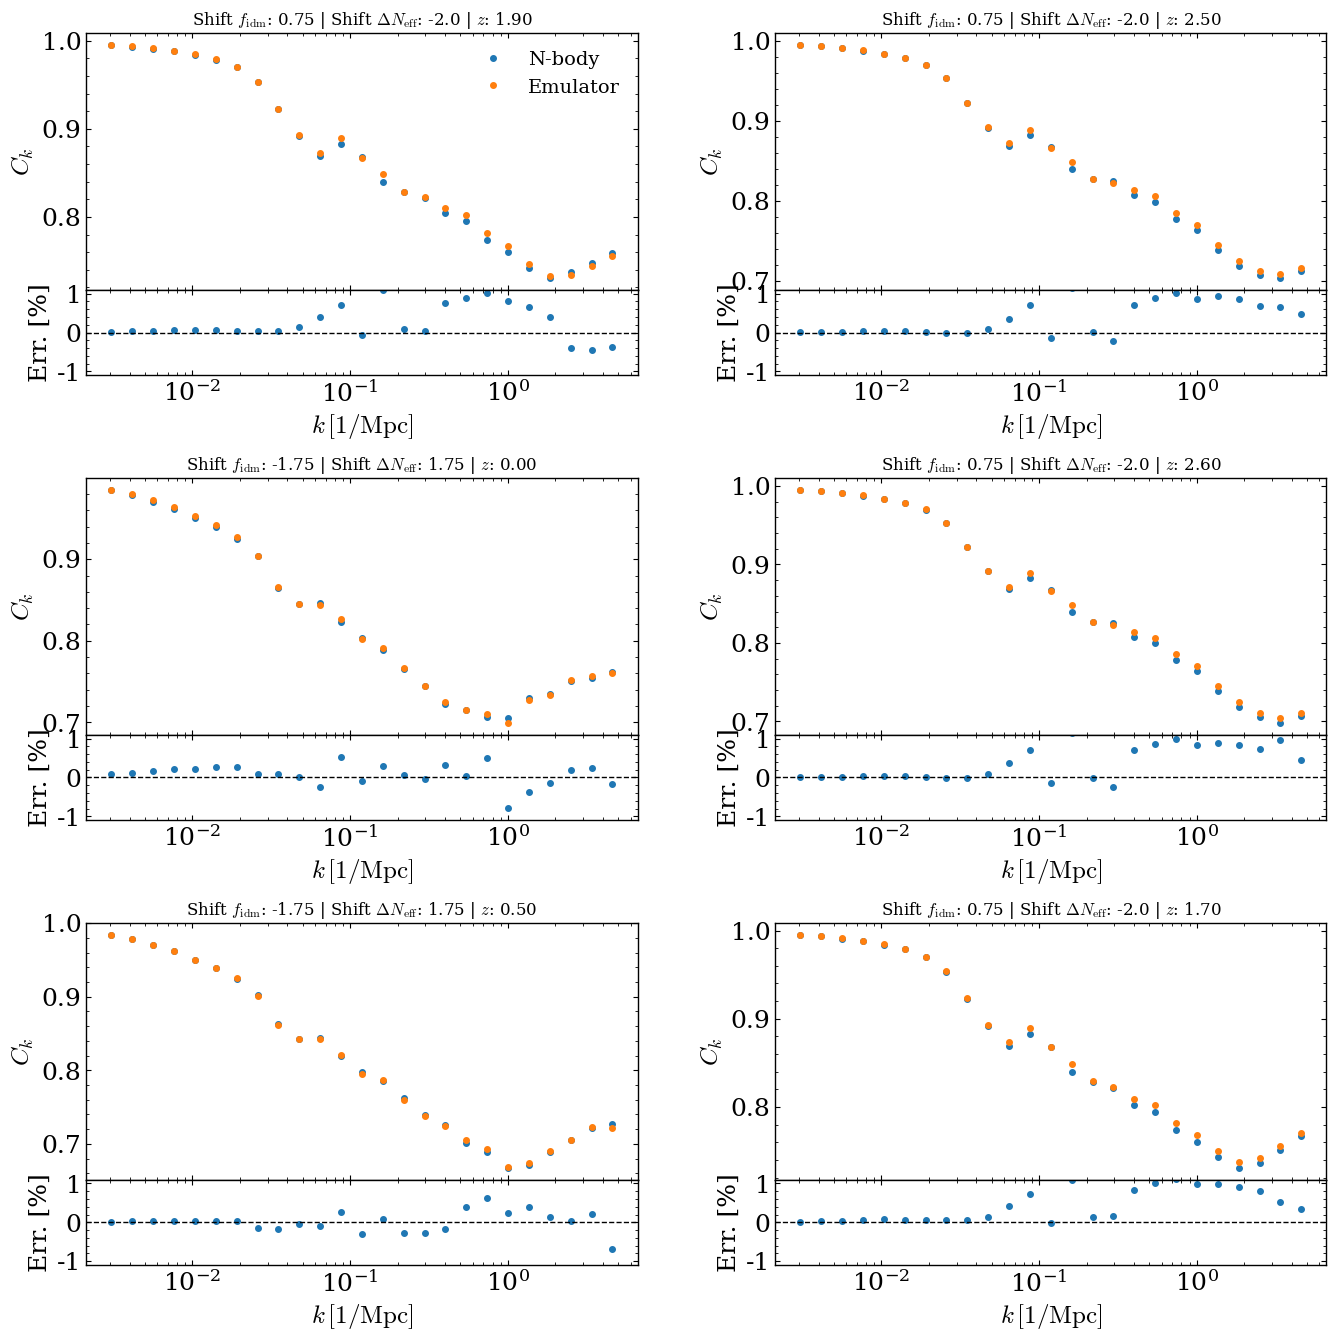

In [7]:
# --- 5. PLOTTING UNSEEN TEST DATA ---
model.eval()
np.random.seed(42)
num_samples = min(6, len(test_dataset))
sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)
k_grid = train_dataset.master_k_grid

baseline_fidm = 0.0285
baseline_dNeff = 0.83
step_dNeff = 0.231 
step_fidm = 0.0076

fig = plt.figure(figsize=(16, 16))
outer_grid = gridspec.GridSpec(3, 2, wspace=0.25, hspace=0.3)

main_axes, res_axes = [], []

for i in range(num_samples):
    row, col = i // 2, i % 2
    inner_grid = outer_grid[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.0)
    
    ax_main = fig.add_subplot(inner_grid[0])
    ax_res = fig.add_subplot(inner_grid[1], sharex=ax_main) 
    ax_main.tick_params(axis='x', labelbottom=False)
    
    main_axes.append(ax_main)
    res_axes.append(ax_res)

with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        inputs, true_Ck = test_dataset[idx]
        pred_Ck = model(inputs.unsqueeze(0)).squeeze(0)
        
        inputs_np = inputs.numpy()
        true_Ck_np = true_Ck.numpy()
        pred_Ck_np = pred_Ck.numpy()
        
        real_inputs = scaler.inverse_transform(inputs_np.reshape(1, -1))[0]
        abs_fidm, abs_dNeff, a_val = real_inputs[0], real_inputs[1], real_inputs[2]
        z = (1.0 / a_val) - 1.0
        
        shift_fidm = round((abs_fidm - baseline_fidm) / step_fidm, 2)
        shift_dNeff = round((abs_dNeff - baseline_dNeff) / step_dNeff, 2)
        
        ax_main = main_axes[i]
        ax_main.plot(k_grid, true_Ck_np, lw=2, label='N-body', ls='None', marker='o', markersize=4)
        ax_main.plot(k_grid, pred_Ck_np, lw=2, label='Emulator', ls='None', marker='o', markersize=4)
        
        ax_main.set_xscale('log')
        ax_main.set_ylabel(r'$C_k$')
        ax_main.set_title(f'Shift $f_{{\\mathrm{{idm}}}}$: {shift_fidm} | Shift $\\Delta N_{{\\mathrm{{eff}}}}$: {shift_dNeff} | $z$: {z:.2f}', fontsize=12)
        
        if i == 0: ax_main.legend()

        ax_res = res_axes[i]
        fractional_error = (pred_Ck_np - true_Ck_np) / (true_Ck_np) * 100
        
        ax_res.plot(k_grid, fractional_error, ls='None', markersize=4, marker='o')
        ax_res.axhline(0, color='k', linestyle='--', lw=1)
        
        ax_res.set_xlabel(r'$k \,[1/\mathrm{Mpc}]$')
        ax_res.set_ylabel('Err. [%]')
        ax_res.set_ylim(-1.1 , 1.1)

plt.show()
# fig.savefig("Alsing_test.pdf", dpi=300, bbox_inches='tight')

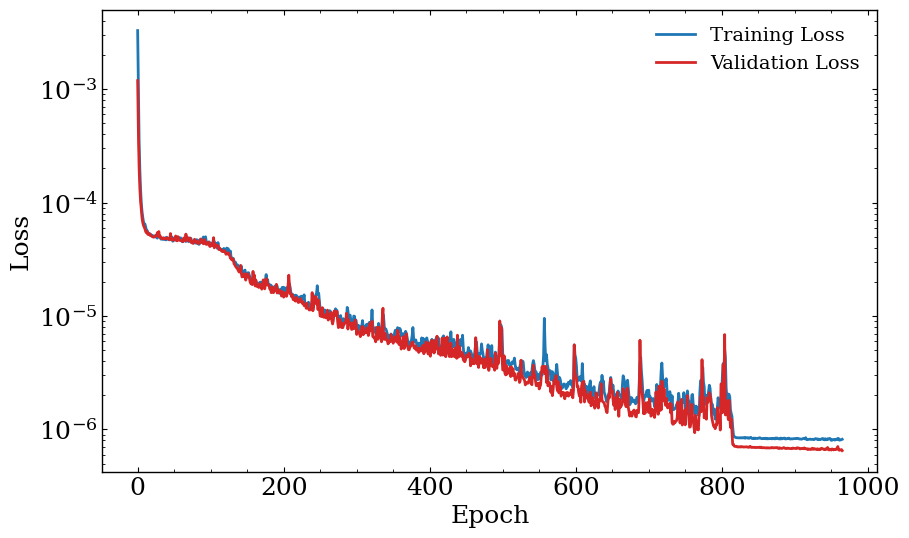

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, label='Training Loss', color='tab:blue', linewidth=2)
ax.plot(val_losses, label='Validation Loss', color='tab:red', linewidth=2)
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

# Save the fig
# fig.savefig("Loss_curve.pdf", dpi=300, bbox_inches='tight')

In [6]:
# # --- SAVE THE EMULATOR ---
# emulator_checkpoint = {
#     'model_state_dict': model.state_dict(),
#     'input_scaler_mean': scaler.mean_,       # From your sklearn StandardScaler
#     'input_scaler_scale': scaler.scale_,     # From your sklearn StandardScaler
#     'k_grid': train_dataset.master_k_grid,    # Save the x-axis for plotting later
# }

# torch.save(emulator_checkpoint, "alsing_emulator_v1.pt")
# print("Emulator successfully saved to alsing_emulator_v1.pt")

In [9]:
import os
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import copy

# --- SETUP ENSEMBLE PARAMETERS ---
total_runs = 5
top_k_to_save = 2
epochs = 3000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Create a directory to keep the outputs organized
output_dir = "top_10_ensembles"
os.makedirs(output_dir, exist_ok=True)

# List to store the results of all 50 runs
all_runs_results = []

# ==========================================
# 1. THE TRAINING ENSEMBLE LOOP
# ==========================================
for run_idx in range(total_runs):
    print(f"\n{'='*40}")
    print(f"Starting Run {run_idx + 1}/{total_runs}")
    print(f"{'='*40}")
    
    # MUST initialize a fresh model and optimizer for every run
    model = DRMD_Emulator(
        target_mean=train_dataset.targets.mean(dim=0),
        target_scale=train_dataset.targets.std(dim=0),
        input_dim=3, 
        output_dim=25,
        hidden_nodes=128,
    ).to(device)

    criterion = FractionalMSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4) 
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=50, min_lr=1e-6)
    
    # min_delta set to 0.0 so tiny fractional improvements are caught
    early_stopping = EarlyStopping(patience=150, min_delta=1e-10) 

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # --- Train Loop ---
        model.train()
        running_train_loss = 0.0
        for batch_inputs, batch_targets in train_loader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
            
            optimizer.zero_grad()
            predictions = model(batch_inputs)
            loss = criterion(predictions, batch_targets)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * batch_inputs.size(0)
            
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        # --- Validation Loop ---
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for batch_inputs, batch_targets in val_loader:
                batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
                
                predictions = model(batch_inputs)
                loss = criterion(predictions, batch_targets)
                running_val_loss += loss.item() * batch_inputs.size(0)
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        scheduler.step(epoch_val_loss)
        early_stopping(epoch_val_loss, model)
        
        if early_stopping.early_stop:
            print(f"Early stopping triggered at Epoch {epoch:03d}")
            break 
            
    # Save the run data into memory (EarlyStopping already holds the deepcopied best weights)
    best_val = early_stopping.best_loss
    all_runs_results.append({
        'run_id': run_idx + 1,
        'best_val_loss': best_val,
        'model_weights': early_stopping.best_model_weights,
        'train_losses': train_losses,
        'val_losses': val_losses
    })
    print(f"Run {run_idx + 1} finished! Best Val Loss: {best_val:.8e}")


# ==========================================
# 2. EVALUATE, PLOT, AND SAVE THE TOP 10
# ==========================================
print("\n" + "="*40)
print(f"EXTRACTING TOP {top_k_to_save} MODELS")
print("="*40)

# Sort the list of dictionaries by the best_val_loss
all_runs_results.sort(key=lambda x: x['best_val_loss'])
top_runs = all_runs_results[:top_k_to_save]

# Parameters for plotting
k_grid = train_dataset.master_k_grid
baseline_fidm = 0.0285
baseline_dNeff = 0.83
step_dNeff = 0.231 
step_fidm = 0.0076

# Lock random seed so the 6 test samples plotted are identical for all 10 models
np.random.seed(42)
num_samples = min(6, len(test_dataset))
sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

for rank, run_data in enumerate(top_runs):
    rank_idx = rank + 1  # 1 to 10
    print(f"Processing Rank #{rank_idx} (Originally Run {run_data['run_id']}) | Val Loss: {run_data['best_val_loss']:.8e}")
    
    # 1. Reload the winning model
    model = DRMD_Emulator(
        target_mean=train_dataset.targets.mean(dim=0),
        target_scale=train_dataset.targets.std(dim=0),
        input_dim=3, 
        output_dim=25,
        hidden_nodes=128,
    ).to(device)
    model.load_state_dict(run_data['model_weights'])
    model.eval()

    # 2. Save the Checkpoint
    checkpoint_path = os.path.join(output_dir, f"emulator_#{rank_idx}.pt")
    emulator_checkpoint = {
        'model_state_dict': model.state_dict(),
        'input_scaler_mean': scaler.mean_,       
        'input_scaler_scale': scaler.scale_,     
        'k_grid': k_grid,   
        'best_val_loss': run_data['best_val_loss']
    }
    torch.save(emulator_checkpoint, checkpoint_path)

    # 3. Plot & Save Loss Curve
    fig_loss, ax_loss = plt.subplots(figsize=(10, 6))
    ax_loss.plot(run_data['train_losses'], label='Training Loss', color='tab:blue', linewidth=2)
    ax_loss.plot(run_data['val_losses'], label='Validation Loss', color='tab:red', linewidth=2)
    ax_loss.set_yscale('log')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    loss_plot_path = os.path.join(output_dir, f"loss_curve_#{rank_idx}.pdf")
    fig_loss.savefig(loss_plot_path, dpi=300, bbox_inches='tight')
    plt.close(fig_loss) # Frees memory

    # 4. Plot & Save Test Data
    fig_test = plt.figure(figsize=(16, 16))
    outer_grid = gridspec.GridSpec(3, 2, wspace=0.25, hspace=0.3)
    main_axes, res_axes = [], []

    for i in range(num_samples):
        row, col = i // 2, i % 2
        inner_grid = outer_grid[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.0)
        ax_main = fig_test.add_subplot(inner_grid[0])
        ax_res = fig_test.add_subplot(inner_grid[1], sharex=ax_main) 
        ax_main.tick_params(axis='x', labelbottom=False)
        main_axes.append(ax_main)
        res_axes.append(ax_res)

    with torch.no_grad():
        for i, idx in enumerate(sample_indices):
            inputs, true_Ck = test_dataset[idx]
            
            # Send inputs to device, extract predictions, send back to CPU for numpy plotting
            inputs_device = inputs.to(device)
            pred_Ck = model(inputs_device.unsqueeze(0)).squeeze(0).cpu()
            
            inputs_np = inputs.numpy()
            true_Ck_np = true_Ck.numpy()
            pred_Ck_np = pred_Ck.numpy()
            
            real_inputs = scaler.inverse_transform(inputs_np.reshape(1, -1))[0]
            abs_fidm, abs_dNeff, a_val = real_inputs[0], real_inputs[1], real_inputs[2]
            z = (1.0 / a_val) - 1.0
            
            shift_fidm = round((abs_fidm - baseline_fidm) / step_fidm, 2)
            shift_dNeff = round((abs_dNeff - baseline_dNeff) / step_dNeff, 2)
            
            ax_main = main_axes[i]
            ax_main.plot(k_grid, true_Ck_np, lw=2, label='N-body', ls='None', marker='o', markersize=4)
            ax_main.plot(k_grid, pred_Ck_np, lw=2, label='Emulator', ls='None', marker='o', markersize=4)
            ax_main.set_xscale('log')
            ax_main.set_ylabel(r'$C_k$')
            ax_main.set_title(f'Shift $f_{{\\mathrm{{idm}}}}$: {shift_fidm} | Shift $\\Delta N_{{\\mathrm{{eff}}}}$: {shift_dNeff} | $z$: {z:.2f}', fontsize=12)
            
            if i == 0: ax_main.legend()

            ax_res = res_axes[i]
            fractional_error = (pred_Ck_np - true_Ck_np) / (true_Ck_np) * 100
            ax_res.plot(k_grid, fractional_error, ls='None', markersize=4, marker='o')
            ax_res.axhline(0, color='k', linestyle='--', lw=1)
            ax_res.set_xlabel(r'$k \,[1/\mathrm{Mpc}]$')
            ax_res.set_ylabel('Err. [%]')
            ax_res.set_ylim(-1.1 , 1.1)

    test_plot_path = os.path.join(output_dir, f"emulator_test_#{rank_idx}.pdf")
    fig_test.savefig(test_plot_path, dpi=300, bbox_inches='tight')
    plt.close(fig_test) # Frees memory

print(f"\nSuccessfully extracted and saved the top {top_k_to_save} models to the '{output_dir}' directory.")

Training on device: cpu

Starting Run 1/5
Early stopping triggered! Best validation loss: 0.00000050
Early stopping triggered at Epoch 2202
Run 1 finished! Best Val Loss: 5.03902199e-07

Starting Run 2/5
Run 2 finished! Best Val Loss: 6.55346547e-07

Starting Run 3/5
Early stopping triggered! Best validation loss: 0.00000037
Early stopping triggered at Epoch 2761
Run 3 finished! Best Val Loss: 3.68308077e-07

Starting Run 4/5
Run 4 finished! Best Val Loss: 3.76202934e-07

Starting Run 5/5
Run 5 finished! Best Val Loss: 5.73036003e-07

EXTRACTING TOP 2 MODELS
Processing Rank #1 (Originally Run 3) | Val Loss: 3.68308077e-07
Processing Rank #2 (Originally Run 4) | Val Loss: 3.76202934e-07

Successfully extracted and saved the top 2 models to the 'top_10_ensembles' directory.


Loading checkpoint from: top_10_ensembles/emulator_#1.pt


/tmp/ipykernel_5554/1551607225.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


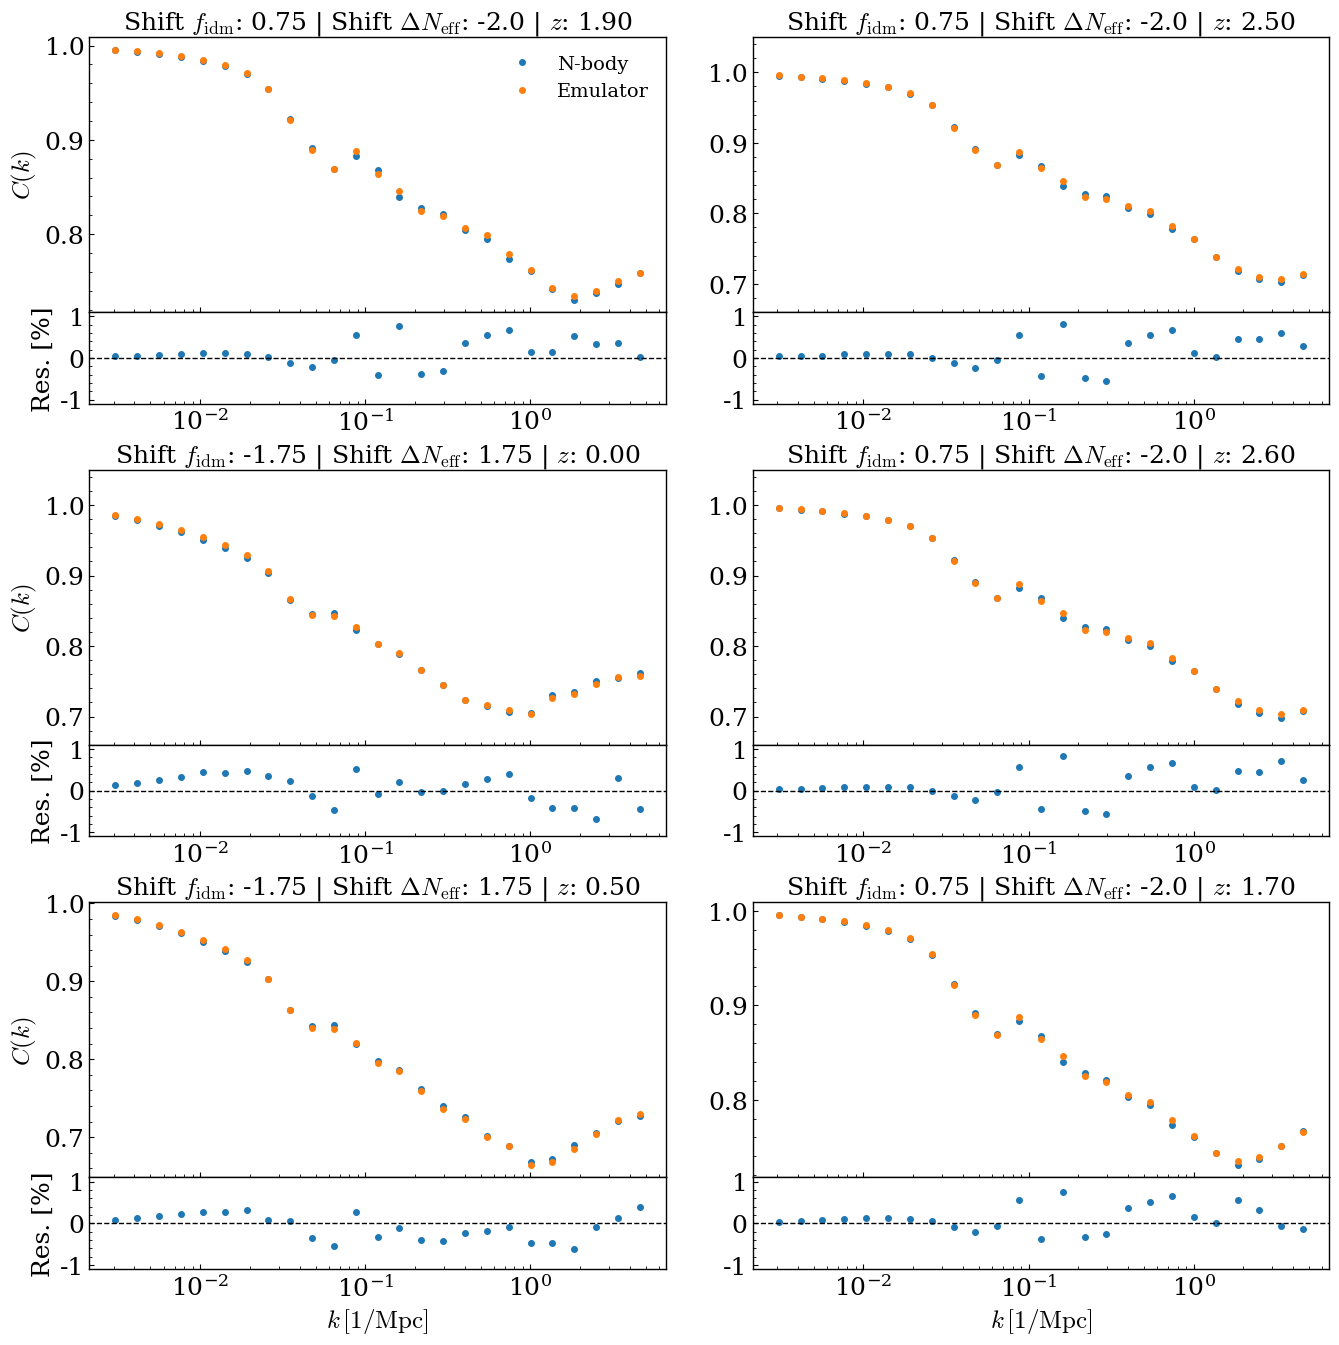

In [23]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib as mpl
import os

# Import your classes from your local file
from NN_no_PCA import DRMD_Emulator, DRMD_Dataset

# --- 1. MATPLOTLIB SETTINGS ---
plt.rcParams.update(plt.rcParamsDefault)
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
})

# --- 2. PATHS & DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/home/storgaard/OneDrive/Speciale/HALOFIT/C_256+2048"
checkpoint_path = "top_10_ensembles/emulator_#1.pt"

# --- 3. LOAD CHECKPOINT & DATA ---
print(f"Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load the test dataset (unscaled initially)
test_dataset = DRMD_Dataset(data_dir, mode='test', baseline_fidm=0.0285, baseline_dNeff=0.83)

# Apply the exact input scaling used during training
mean_in = checkpoint['input_scaler_mean']
scale_in = checkpoint['input_scaler_scale']
test_inputs_scaled = (test_dataset.inputs.numpy() - mean_in) / scale_in
test_dataset.inputs = torch.tensor(test_inputs_scaled, dtype=torch.float32)

# --- 4. INITIALIZE & LOAD MODEL ---
# The target_mean and target_scale are stored as buffers in the state_dict.
# We pass dummy arrays to __init__, and load_state_dict() will overwrite them with the real ones.
dummy_mean = torch.zeros(25)
dummy_scale = torch.ones(25)

model = DRMD_Emulator(
    target_mean=dummy_mean,
    target_scale=dummy_scale,
    input_dim=3, 
    output_dim=25,
    hidden_nodes=128
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# --- 5. PLOTTING SETUP ---
k_grid = checkpoint['k_grid']
baseline_fidm = 0.0285
baseline_dNeff = 0.83
step_dNeff = 0.231 
step_fidm = 0.0076

# Lock random seed to get the same 6 plots as before, or remove to see new ones
np.random.seed(42)
num_samples = min(6, len(test_dataset))
sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

fig = plt.figure(figsize=(16, 16))
outer_grid = gridspec.GridSpec(3, 2, wspace=0.15, hspace=0.18)
main_axes, res_axes = [], []

for i in range(num_samples):
    row, col = i // 2, i % 2
    inner_grid = outer_grid[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.0)
    
    ax_main = fig.add_subplot(inner_grid[0])
    ax_res = fig.add_subplot(inner_grid[1], sharex=ax_main) 
    ax_main.tick_params(axis='x', labelbottom=False)
    
    main_axes.append(ax_main)
    res_axes.append(ax_res)

# --- 6. INFERENCE & PLOTTING LOOP ---
with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        inputs, true_Ck = test_dataset[idx]
        
        inputs_device = inputs.to(device)
        pred_Ck = model(inputs_device.unsqueeze(0)).squeeze(0).cpu()
        
        inputs_np = inputs.numpy()
        true_Ck_np = true_Ck.numpy()
        pred_Ck_np = pred_Ck.numpy()
        
        # change the y-axis lims for the main plot for subplot 2, 3 and 4 to better visualize the differences
        if i in [2, 3, 4]:
            ax_main.set_ylim(0.66, 1.05)
        
        # Inverse transform the inputs to get physical parameters for the title
        real_inputs = (inputs_np * scale_in) + mean_in
        abs_fidm, abs_dNeff, a_val = real_inputs[0], real_inputs[1], real_inputs[2]
        z = abs((1.0 / a_val) - 1.0)
        
        shift_fidm = round((abs_fidm - baseline_fidm) / step_fidm, 2)
        shift_dNeff = round((abs_dNeff - baseline_dNeff) / step_dNeff, 2)
        
        ax_main = main_axes[i]
        ax_main.plot(k_grid, true_Ck_np, lw=2, label='N-body', ls='None', marker='o', markersize=4)
        ax_main.plot(k_grid, pred_Ck_np, lw=2, label='Emulator', ls='None', marker='o', markersize=4)
        
        ax_main.set_xscale('log')
        ax_main.set_title(f'Shift $f_{{\\mathrm{{idm}}}}$: {shift_fidm} | Shift $\\Delta N_{{\\mathrm{{eff}}}}$: {shift_dNeff} | $z$: {z:.2f}')
        
        if i == 0: ax_main.legend()

        ax_res = res_axes[i]
        fractional_error = (pred_Ck_np - true_Ck_np) / (true_Ck_np) * 100
        
        ax_res.plot(k_grid, fractional_error, ls='None', markersize=4, marker='o')
        ax_res.axhline(0, color='k', linestyle='--', lw=1)
        
        # Only have x-label on the bottom subplots to avoid clutter
        if i in [4, 5]:
            ax_res.set_xlabel(r'$k \,[1/\mathrm{Mpc}]$')
        if i in [0, 2, 4]:  # Only have y-label on the left subplots to avoid clutter
            ax_res.set_ylabel('Res. [%]')
            ax_main.set_ylabel(r'$C(k)$')
        ax_res.set_ylim(-1.1 , 1.1)

plt.show()
# Save the plot
fig.savefig("emulator_test.pdf", dpi=300, bbox_inches='tight')

Loading checkpoint from: top_10_ensembles/emulator_#1.pt


/tmp/ipykernel_5554/3009639865.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


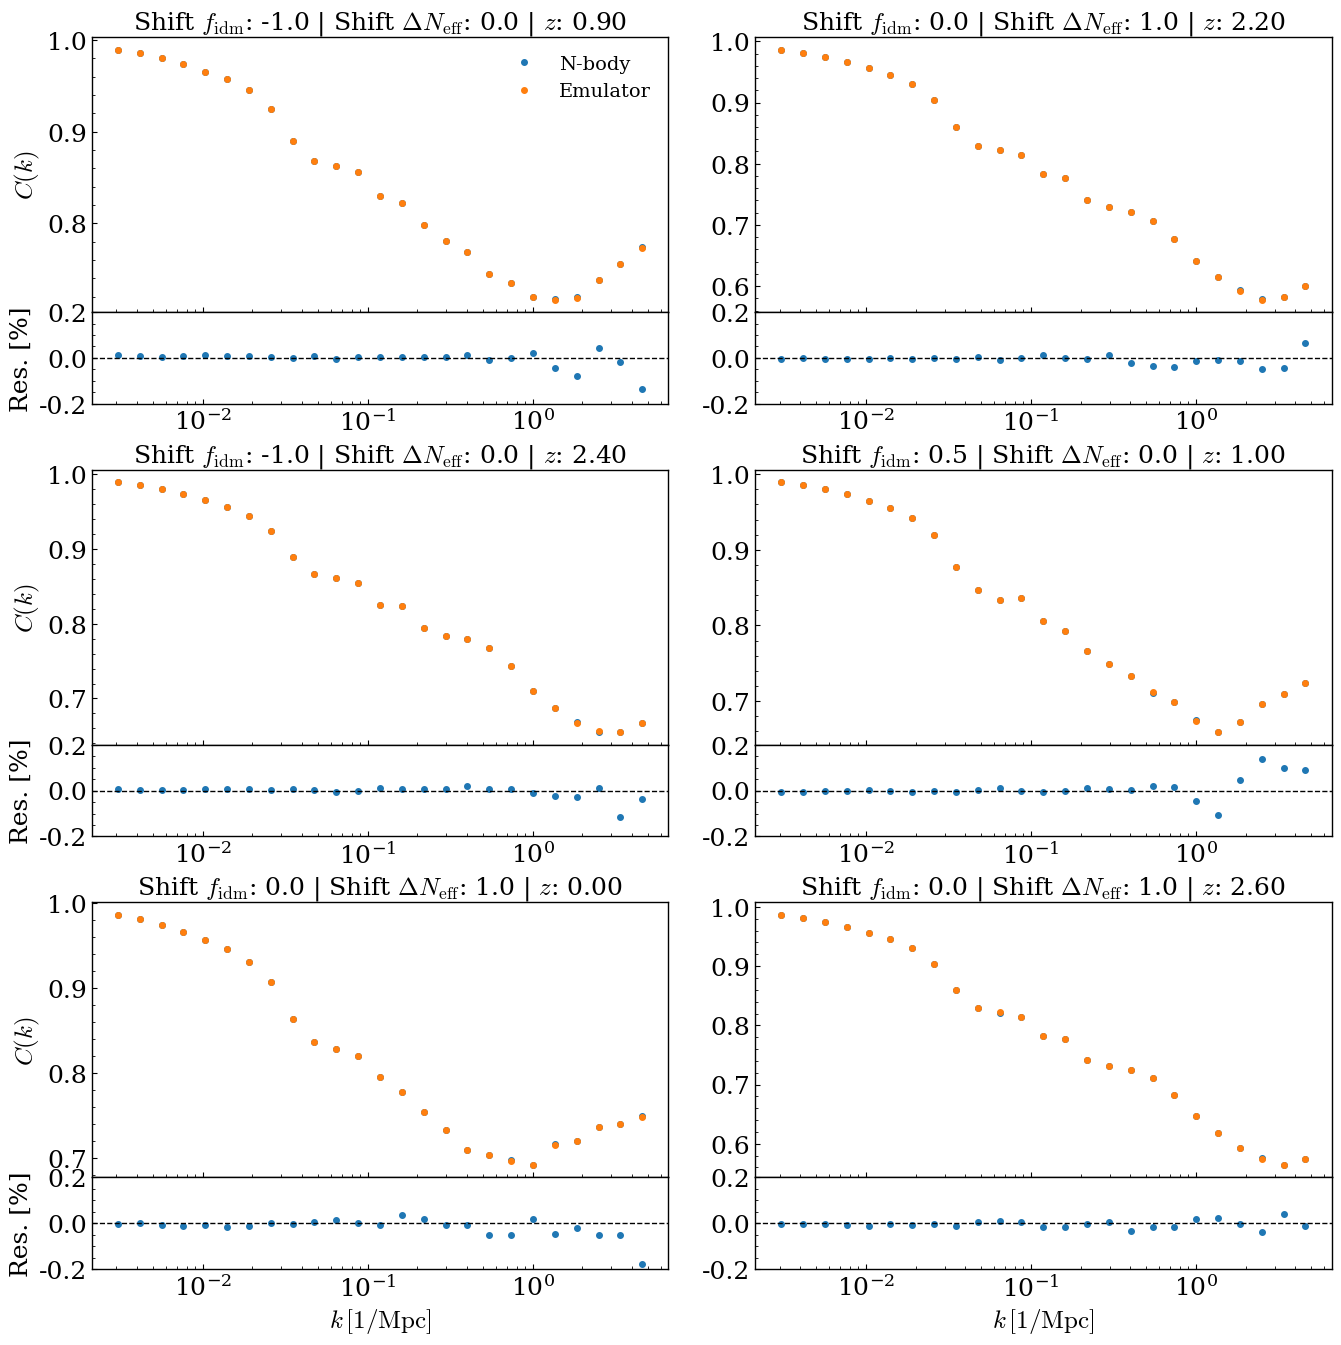

In [30]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib as mpl
import os

# Import your classes from your local file
from NN_no_PCA import DRMD_Emulator, DRMD_Dataset

# --- 1. MATPLOTLIB SETTINGS ---
plt.rcParams.update(plt.rcParamsDefault)
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
})

# --- 2. PATHS & DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/home/storgaard/OneDrive/Speciale/HALOFIT/C_256+2048"
checkpoint_path = "top_10_ensembles/emulator_#1.pt"

# --- 3. LOAD CHECKPOINT & DATA ---
print(f"Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load the VALIDATION dataset (unscaled initially)
val_dataset = DRMD_Dataset(data_dir, mode='val', baseline_fidm=0.0285, baseline_dNeff=0.83)

# Apply the exact input scaling used during training
mean_in = checkpoint['input_scaler_mean']
scale_in = checkpoint['input_scaler_scale']
val_inputs_scaled = (val_dataset.inputs.numpy() - mean_in) / scale_in
val_dataset.inputs = torch.tensor(val_inputs_scaled, dtype=torch.float32)

# --- 4. INITIALIZE & LOAD MODEL ---
dummy_mean = torch.zeros(25)
dummy_scale = torch.ones(25)

model = DRMD_Emulator(
    target_mean=dummy_mean,
    target_scale=dummy_scale,
    input_dim=3, 
    output_dim=25,
    hidden_nodes=128
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# --- 5. PLOTTING SETUP ---
k_grid = checkpoint['k_grid']
baseline_fidm = 0.0285
baseline_dNeff = 0.83
step_dNeff = 0.231 
step_fidm = 0.0076

# Lock random seed to get consistent plots when rerunning the cell
np.random.seed(42)
num_samples = min(6, len(val_dataset))
sample_indices = np.random.choice(len(val_dataset), num_samples, replace=False)

fig = plt.figure(figsize=(16, 16))
outer_grid = gridspec.GridSpec(3, 2, wspace=0.15, hspace=0.18)
main_axes, res_axes = [], []

for i in range(num_samples):
    row, col = i // 2, i % 2
    inner_grid = outer_grid[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.0)
    
    ax_main = fig.add_subplot(inner_grid[0])
    ax_res = fig.add_subplot(inner_grid[1], sharex=ax_main) 
    ax_main.tick_params(axis='x', labelbottom=False)
    
    main_axes.append(ax_main)
    res_axes.append(ax_res)

# --- 6. INFERENCE & PLOTTING LOOP ---
with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        inputs, true_Ck = val_dataset[idx]
        
        inputs_device = inputs.to(device)
        pred_Ck = model(inputs_device.unsqueeze(0)).squeeze(0).cpu()
        
        inputs_np = inputs.numpy()
        true_Ck_np = true_Ck.numpy()
        pred_Ck_np = pred_Ck.numpy()
        
        # NOTE: Commented out the hardcoded y-limits as the random val samples 
        # will have different absolute magnitudes than the test samples.
        # if i in [2, 3, 4]:
        #     ax_main.set_ylim(0.66, 1.05)
        
        real_inputs = (inputs_np * scale_in) + mean_in
        abs_fidm, abs_dNeff, a_val = real_inputs[0], real_inputs[1], real_inputs[2]
        # Make sure if the param shift values are 0.0 they are positive zeros for cleaner titles
        z = abs((1.0 / a_val) - 1.0)
        
        shift_fidm = round((abs_fidm - baseline_fidm) / step_fidm, 2)
        shift_dNeff = round((abs_dNeff - baseline_dNeff) / step_dNeff, 2)
        if abs(shift_fidm) < 1e-5: shift_fidm = 0.0
        if abs(shift_dNeff) < 1e-5: shift_dNeff = 0.0
        
        ax_main = main_axes[i]
        ax_main.plot(k_grid, true_Ck_np, lw=2, label='N-body', ls='None', marker='o', markersize=4)
        ax_main.plot(k_grid, pred_Ck_np, lw=2, label='Emulator', ls='None', marker='o', markersize=4)
        
        ax_main.set_xscale('log')
        ax_main.set_title(f'Shift $f_{{\\mathrm{{idm}}}}$: {shift_fidm} | Shift $\\Delta N_{{\\mathrm{{eff}}}}$: {shift_dNeff} | $z$: {z:.2f}')
        
        if i == 0: ax_main.legend()

        ax_res = res_axes[i]
        fractional_error = (pred_Ck_np - true_Ck_np) / (true_Ck_np) * 100
        
        ax_res.plot(k_grid, fractional_error, ls='None', markersize=4, marker='o')
        ax_res.axhline(0, color='k', linestyle='--', lw=1)
        
        if i in [4, 5]:
            ax_res.set_xlabel(r'$k \,[1/\mathrm{Mpc}]$')
        if i in [0, 2, 4]:  
            ax_res.set_ylabel('Res. [%]')
            ax_main.set_ylabel(r'$C(k)$')
        ax_res.set_ylim(-0.2 , 0.2)

plt.show()

# Save the plot with a new name to avoid overwriting the test plot
fig.savefig("emulator_val.pdf", dpi=300, bbox_inches='tight')

Loading checkpoint from: top_10_ensembles/emulator_#1.pt


/tmp/ipykernel_5554/1080214917.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


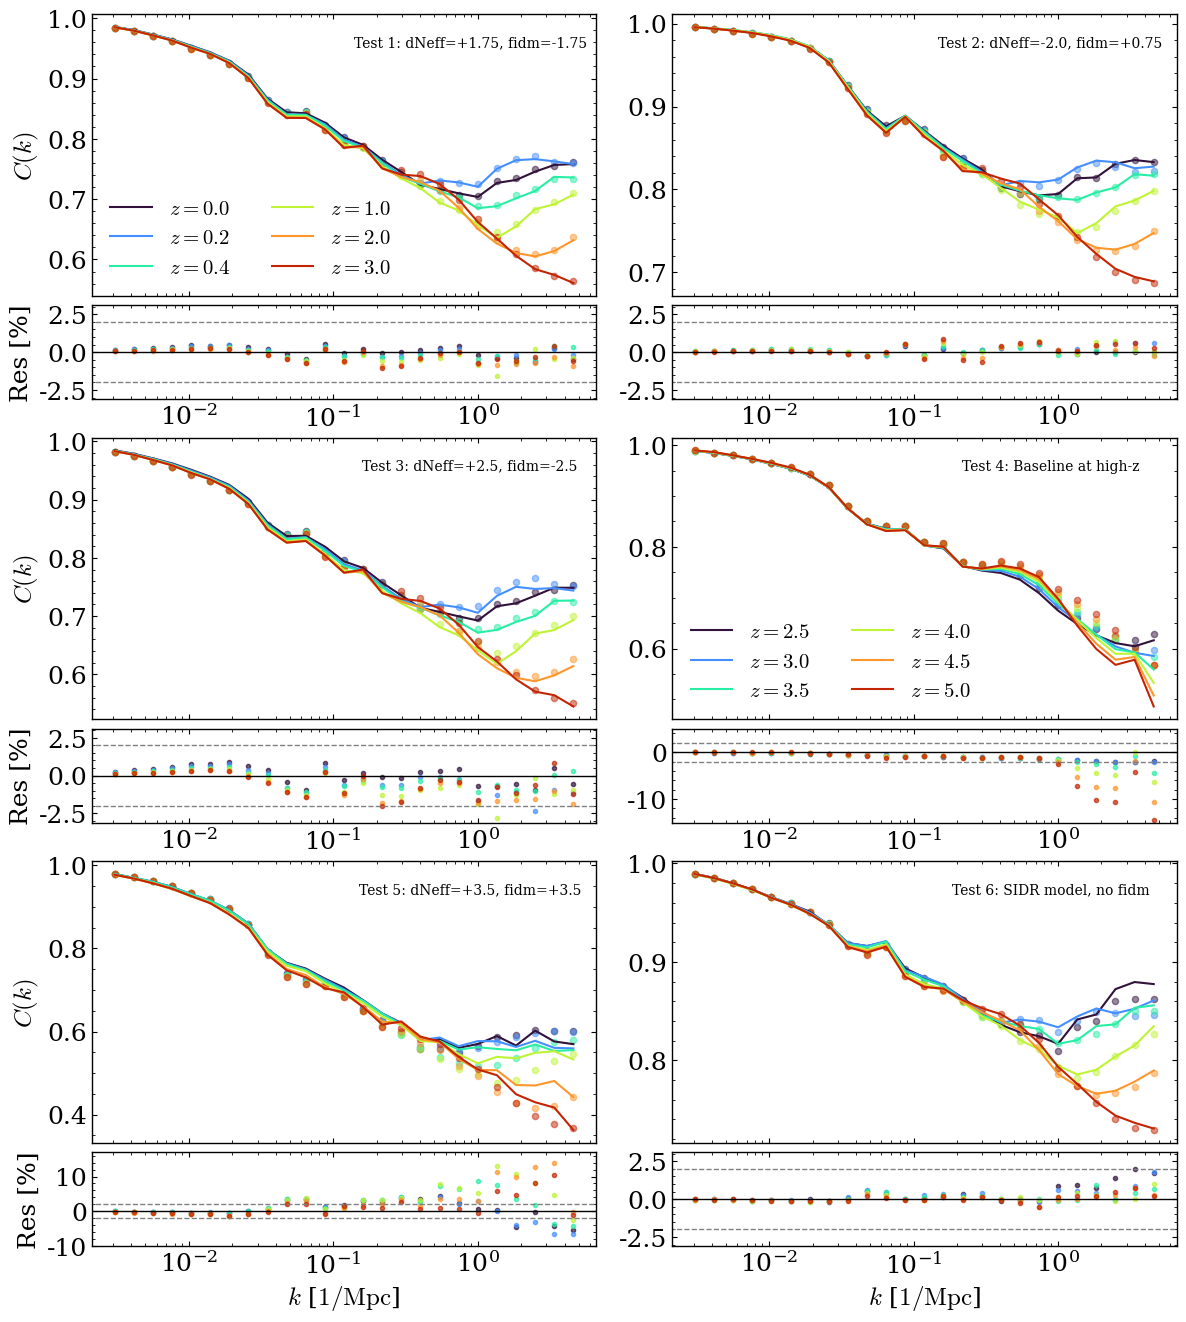

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import matplotlib as mpl
import matplotlib.cm as cm
from scipy.interpolate import interp1d
from NN_no_PCA import DRMD_Emulator

# --- 1. MATPLOTLIB SETTINGS ---
plt.rcParams.update(plt.rcParamsDefault)
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

# --- 2. PATHS, DEVICE & MODEL LOADING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_path = "/home/storgaard/OneDrive/Speciale/HALOFIT/C_256+2048"
checkpoint_path = "top_10_ensembles/emulator_#1.pt"

print(f"Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device)

k_grid = checkpoint['k_grid']
mean_in = checkpoint['input_scaler_mean']
scale_in = checkpoint['input_scaler_scale']

dummy_mean = torch.zeros(25)
dummy_scale = torch.ones(25)

model = DRMD_Emulator(
    target_mean=dummy_mean,
    target_scale=dummy_scale,
    input_dim=3, 
    output_dim=25,
    hidden_nodes=128
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# --- 3. TEST PARAMETERS (Same as Padé script) ---
folders = ["test_1", "test_3", "test_4", "test_5", "test_6", "test_7"]
params = {
    "test_1": {"dNeff": 1.75, "fidm": -1.75},
    "test_3": {"dNeff": -2.0, "fidm": 0.75},
    "test_4": {"dNeff": 2.5, "fidm": -2.5},
    "test_5": {"dNeff": 0.2, "fidm": 0.1, "custom_z": [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]},
    "test_6": {"dNeff": 3.5, "fidm": 3.5},
    "test_7": {"dNeff": 0, "fidm": -3.75}
}
default_zs = [0.0, 0.2, 0.4, 1.0, 2.0, 3.0]

baseline_fidm = 0.0285
baseline_dNeff = 0.83
step_dNeff = 0.231 
step_fidm = 0.0076
num_bins = 25
res_lims = [-3.1, 3.1]

# --- 4. PLOTTING LOOP ---
rows, cols = 3, 2
fig = plt.figure(figsize=(14, 16))
gs_outer = gridspec.GridSpec(rows, cols, wspace=0.15, hspace=0.10)

with torch.no_grad():
    for i, folder in enumerate(folders):
        row = i // cols
        col = i % cols
        
        test_params = params.get(folder, {})
        dNeff_shift = test_params.get("dNeff", 0)
        fidm_shift = test_params.get("fidm", 0)
        
        if "test_5" in folder or "custom_z" in test_params:
            z_list = test_params.get("custom_z", [0.0, 0.5, 1.0, 2.0])
        else:
            z_list = default_zs

        gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[i], 
                                                    height_ratios=[3, 1], hspace=0.05)
        ax_main = fig.add_subplot(gs_inner[0])
        ax_res  = fig.add_subplot(gs_inner[1], sharex=ax_main)
        
        colors = cm.turbo(np.linspace(0, 0.9, len(z_list)))

        for j, z in enumerate(z_list):
            file_name = f"Ck_z{z:.2f}.txt"
            file_path = os.path.join(base_path, folder, file_name)
            color = colors[j]
            
            try:
                # 1. Load N-body data and interpolate to match Emulator k_grid exactly
                data_full = np.loadtxt(file_path, skiprows=1, usecols=(0, 1))
                current_k = data_full[:, 0]
                current_Ck = data_full[:, 1]
                
                f_interp = interp1d(current_k, current_Ck, kind='linear', bounds_error=False, fill_value="extrapolate")
                true_Ck_np = f_interp(k_grid)

                # 2. Prepare physical inputs
                abs_dNeff = baseline_dNeff + (dNeff_shift * step_dNeff)
                abs_fidm = baseline_fidm + (fidm_shift * step_fidm)
                a_val = 1.0 / (1.0 + z)
                
                # 3. Scale inputs for the network
                raw_inputs = np.array([abs_fidm, abs_dNeff, a_val])
                inputs_scaled = (raw_inputs - mean_in) / scale_in
                
                inputs_tensor = torch.tensor(inputs_scaled, dtype=torch.float32).unsqueeze(0).to(device)
                
                # 4. Get Emulator Prediction
                pred_Ck = model(inputs_tensor).squeeze(0).cpu().numpy()

                # 5. Calculate Residuals (%)
                residuals_pct = (pred_Ck / true_Ck_np - 1) * 100

                # --- Plot Main ---
                ax_main.scatter(k_grid, true_Ck_np, color=color, alpha=0.5, s=20, marker='o')
                ax_main.plot(k_grid, pred_Ck, color=color, lw=1.5, label=f'$z = {z}$', zorder=10)

                # --- Plot Residuals ---
                ax_res.plot(k_grid, residuals_pct, 'o', markersize=3, color=color, alpha=0.7)

            except FileNotFoundError:
                print(f"Warning: File {file_path} not found. Skipping redshift z={z} for {folder}.")

        # --- Formatting Subtitles ---
        names = {
            "test_1": "Test 1: dNeff=+1.75, fidm=-1.75",
            "test_3": "Test 2: dNeff=-2.0, fidm=+0.75",
            "test_4": "Test 3: dNeff=+2.5, fidm=-2.5",
            "test_5": "Test 4: Baseline at high-z",
            "test_6": "Test 5: dNeff=+3.5, fidm=+3.5",
            "test_7": "Test 6: SIDR model, no fidm"
        }
        ax_main.text(0.75, 0.90, f"{names.get(folder, folder)}", transform=ax_main.transAxes, 
                     verticalalignment='center', horizontalalignment='center', 
                     fontsize=10, color='k', fontname='Serif')

        # --- Formatting Main Panel ---
        ax_main.set_xscale('log')
        if col == 0:
            ax_main.set_ylabel(r'$C(k)$')
        if row == 0 and col == 0:
            ax_main.legend(frameon=False, loc='lower left', fontsize='small', ncol=2)
        if "test_5" in folder:
            ax_main.legend(frameon=False, loc='lower left', fontsize='small', ncol=2)
        plt.setp(ax_main.get_xticklabels(), visible=False)

        # --- Formatting Residual Panel ---
        ax_res.axhline(0, color='black', lw=1, ls='-')
        ax_res.hlines([2, -2], color='grey', lw=1, ls='--', xmin=1e-3, xmax=1e1)
        
        if col == 0:
            ax_res.set_ylabel(r'Res [%]')
        
        # Exact matching of the Padé Y-limits to show how much flatter the emulator is
        ax_res.set_ylim(*res_lims)
        if "test_5" in folder:
            ax_res.set_ylim(-15, 5)
        elif "test_6" in folder:
            ax_res.set_ylim(-10, 17)
        
        if row == rows - 1:
            ax_res.set_xlabel(r'$k$ [$1/\mathrm{Mpc}$]')

# Save the plot
# fig.savefig("6_tests_comparison_emulator.pdf", dpi=300, bbox_inches='tight')
plt.show()